# Finalize `ofi_ema` for the model — a single-span (1-D param) feature

`ofi_ema` (the path-sum Order-Flow Imbalance, one EMA per venue) **cleared screening** — it is computed
correctly and carries real signal. This is **step 2 — finalize it for the model**: pick the time-scale per
head, shape the feature for the network, decide single-vs-per-exchange, and run the ship checklist.

This is the **1-D-param** version (the span family is a single EMA span `N`, swept as a line). For a
fast/slow feature (two spans, e.g. `price_dislocation`), use [`02_finalize_2d.ipynb`](02_finalize_2d.ipynb),
which sweeps a fast/slow grid instead.

Wiring only — the engines are shared, tested code: span/head selection (`boba.research.selection`), input
shaping (`boba.research.shaping`). The **method** is in [`METHOD.md`](METHOD.md).

We evaluate on an **event-gated grid** (`build_context(grid_ms=1, active_only=True, hours=2)`): a regular
1 ms grid, keeping only the ms windows that carried an event (book update or trade) from *any* exchange,
over the first 2 h of the block. `grid_ms` sets the resolution (raise it if compute is heavy) and `hours`
caps how much of the block is read.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
pl.Config.set_tbl_rows(-1); pl.Config.set_tbl_cols(-1)       # every pl.DataFrame: show ALL rows and columns,
pl.Config.set_fmt_str_lengths(1000); pl.Config.set_tbl_width_chars(10_000)   # never truncate strings or by width
from boba.features import base
import boba.features.ofi_ema                                # registers the feature
from boba.research.screening import build_context, build_family, best_span
from boba.research.selection import fixed_move_targets, ic_scan, per_exchange_vs_single
from boba.research.shaping import shaping_report

ctx  = build_context(grid_ms=1, active_only=True, hours=2)   # 1 ms grid, keep only ms windows with an event (any venue); first 2 h
spec = base.get("ofi_ema")
SPANS = sorted([1, 10, 50, 100, 500, 1000, 2000, 5000, 10000])               # the single-EMA-span family (params = N)
KEYS  = spec.keys_for(ctx, SPANS[0])                        # the feature's leg keys (per-exchange) — works for any feature
family = build_family(ctx, spec.vectorized, SPANS, n_jobs=18)                 # {N: {leg: vector}}
print(f"block {ctx.block}   {len(SPANS)} spans   feature legs {KEYS}")
print(f"{len(ctx.anchor_ts):,} examples (anchors) on the event-gated grid   from {len(ctx.merged_ts):,} trade ticks")

def show_scan(scans, title):                                                 # IC vs span, one line per leg (the 1-D plotter)
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    x = range(len(SPANS))
    for leg, arr in scans.items():
        ax.plot(x, arr, "o-", label=leg)
    ax.set_xticks(list(x)); ax.set_xticklabels(SPANS, rotation=45); ax.set_xlabel("EMA span N")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(title); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

block holocron.20260520T135822.0   9 spans   feature legs ('byb', 'bin', 'okx')
1,306,767 examples (anchors) on the event-gated grid   from 304,617 trade ticks


## 1. Which time-scale per head? — the IC breakdown

Where the signal lives across the single-span family, per leg — the same diagnostics as the 2-D notebook,
but a **1-D scan** over `N` (a line per leg) instead of a fast/slow heatmap:
- **price head, count-conditioned (the `D_k` family)** — the signed feature vs the signed `n`-move
  return, and `|feature|` vs `|n-move return|`, for the `fixed_move_targets`;
- **rate head** — `|feature|` vs the move count.

The price scans score against a *range of fixed mid-move-count* targets (not the 100 ms wall-clock return).
The signed price scans are **mirror-augmented** (the tape reflected through byb's mid via the feature's own
`spec.mirror`, here `np.negative`) so the IC is direction-free — see
[`AUTHORING.md`](../../src/boba/features/AUTHORING.md) → Mirror augmentation. (Held-out span *selection*
across blocks is the OOS harness; these in-sample scans pick a representative scale.)

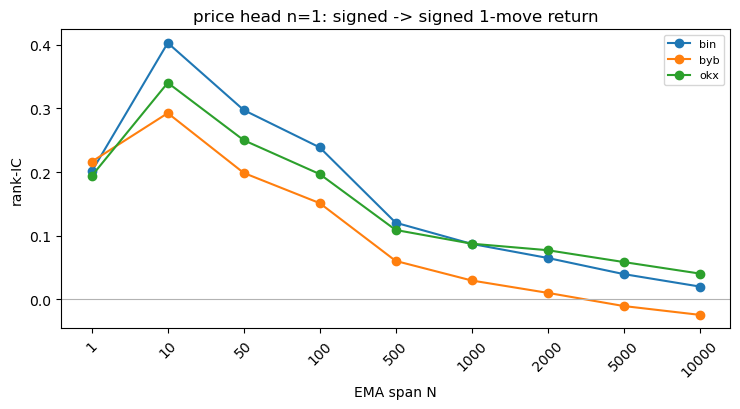

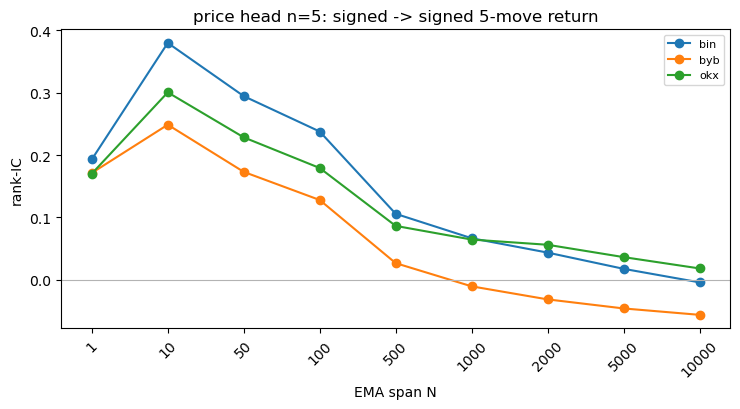

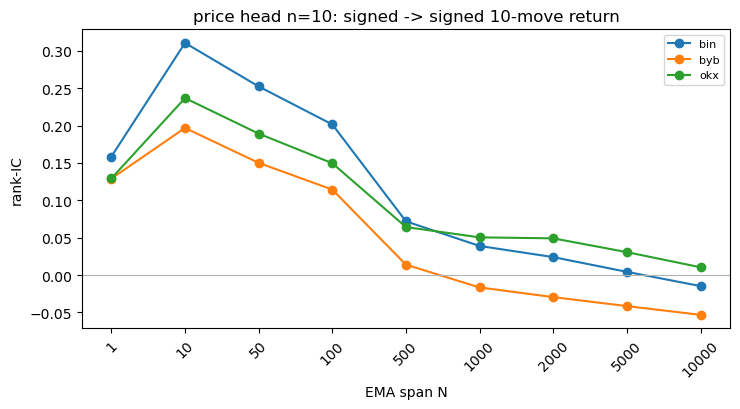

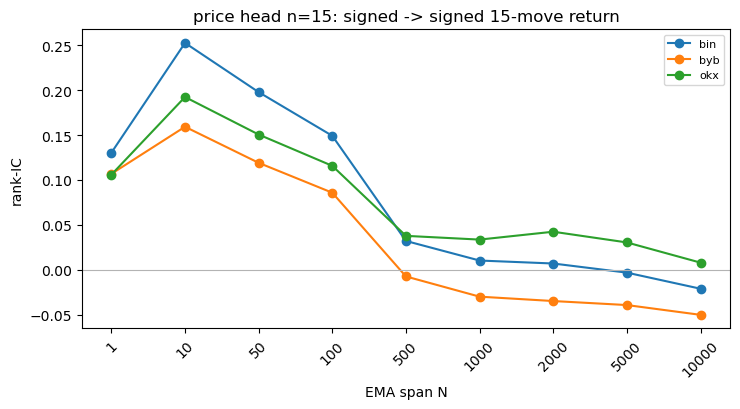

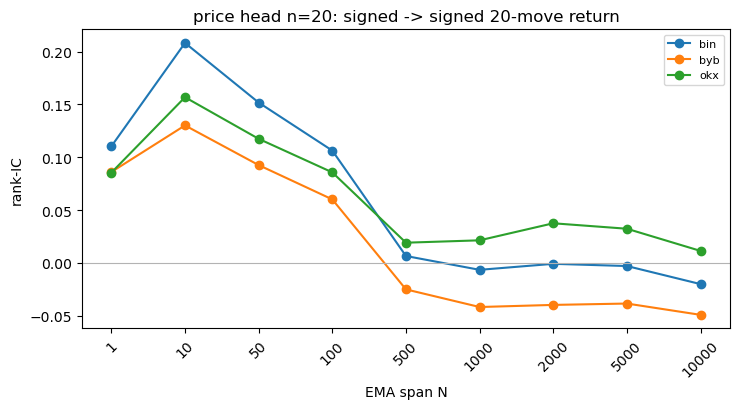

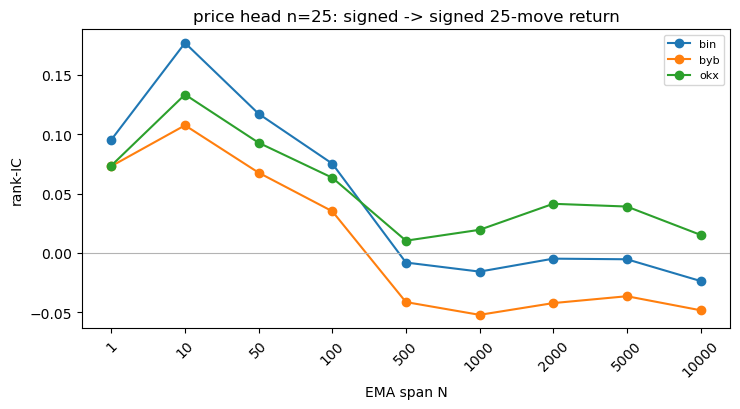

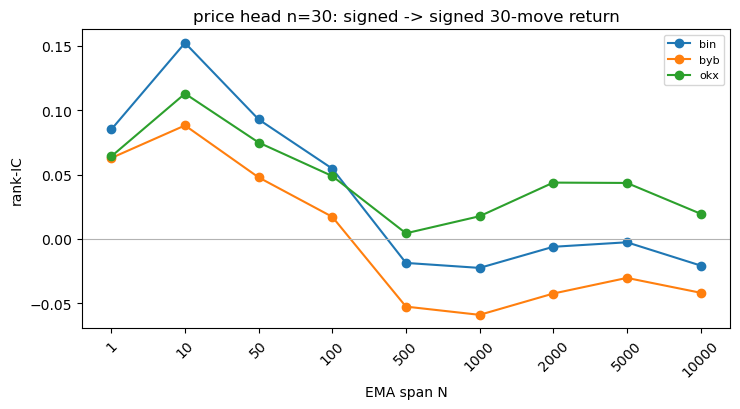

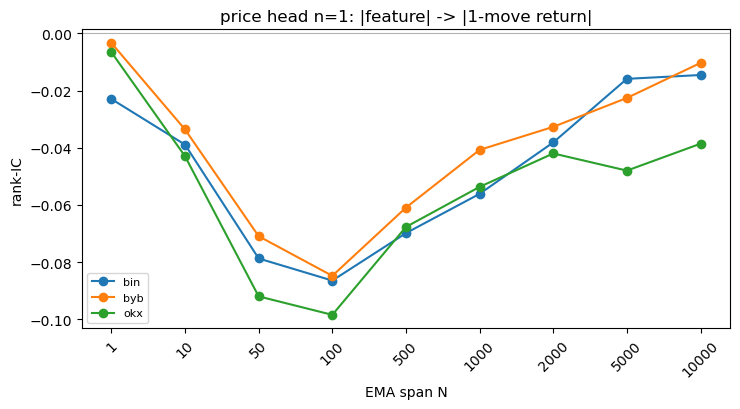

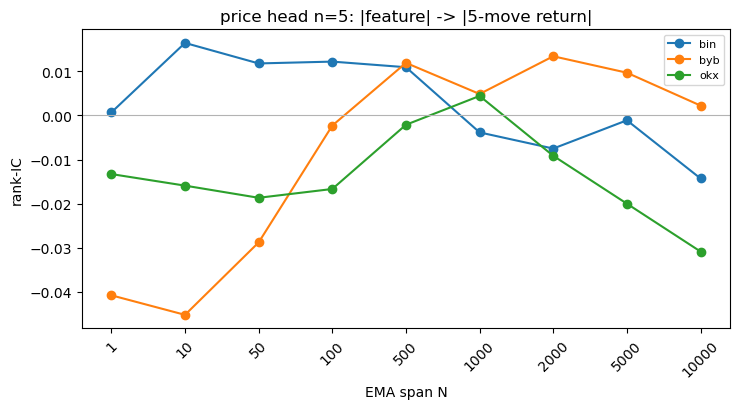

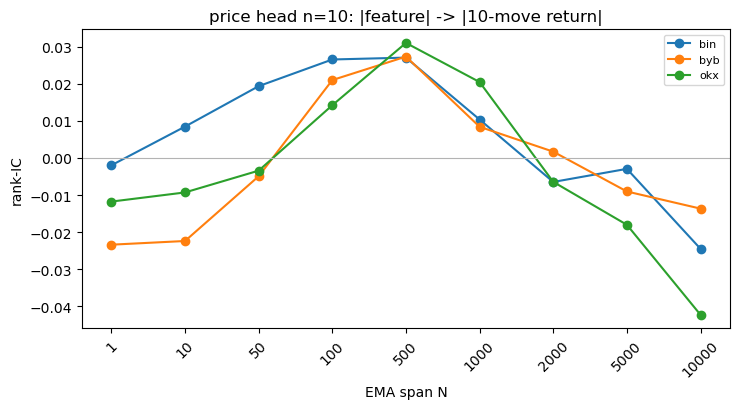

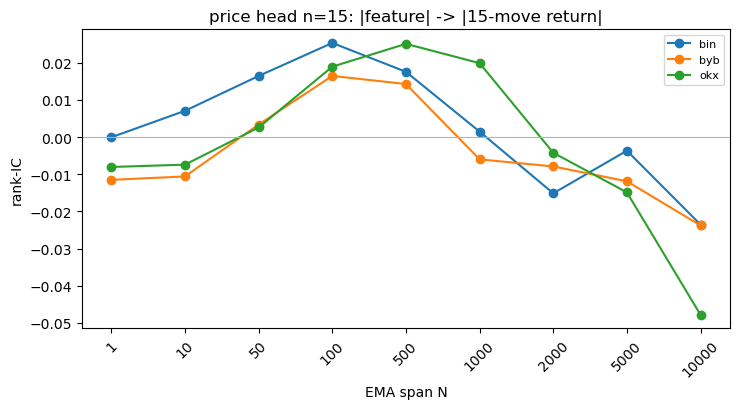

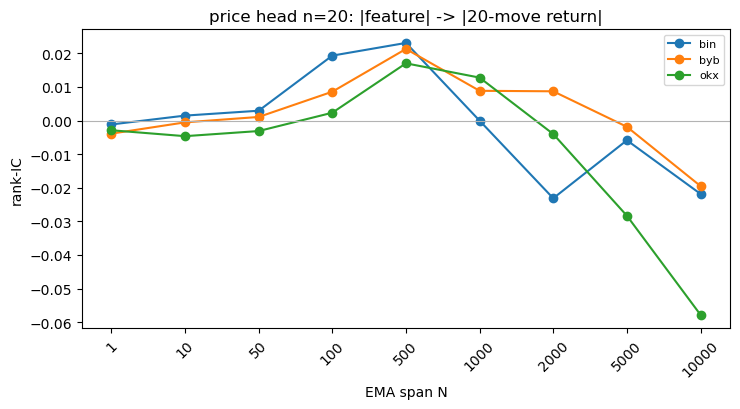

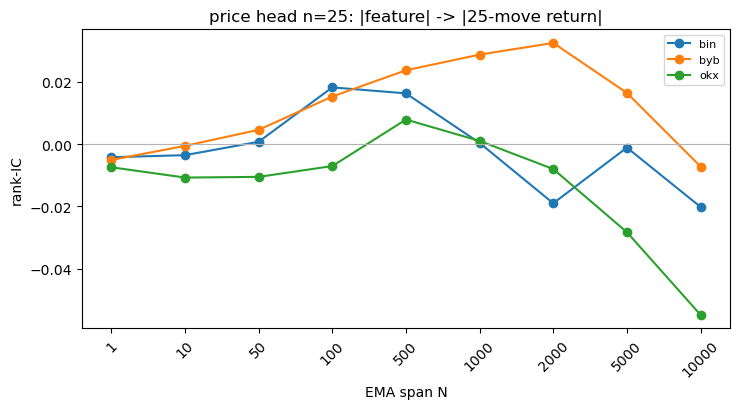

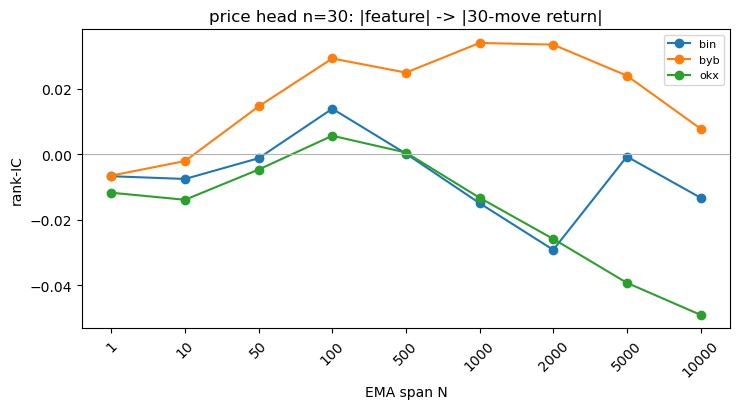

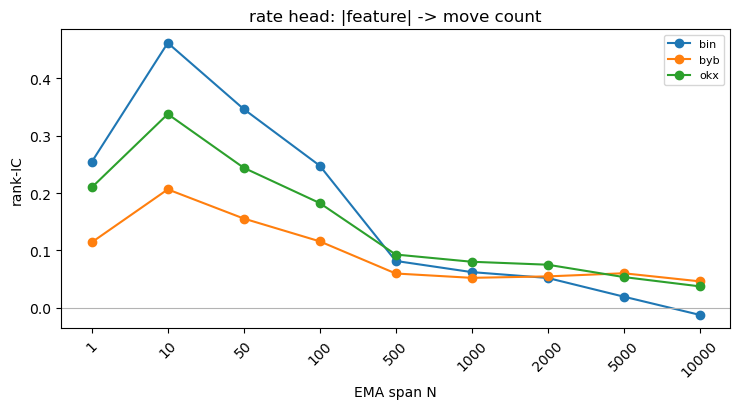

In [2]:
# the IC sweep — count-conditioned price scans over the range of move-counts + the rate scan. No 100 ms
# target. fixed_move_targets / ic_scan are the shared, tested engines (boba.research.selection; ic_scan
# threads its scoring at n_jobs); show_scan is the §0 plotter above.
fmt = fixed_move_targets(ctx)                                                # {n: signed n-move return / σ_ev}
signed = {n: ic_scan(ctx, family, t, n_jobs=18, mirror=spec.mirror)     for n, t in fmt.items()}   # signed feature -> signed n-move return (mirror-augmented)
magnit = {n: ic_scan(ctx, family, np.abs(t), magnitude=True, n_jobs=18) for n, t in fmt.items()}   # |feature| -> |n-move return| (sign-blind: no mirror)
rate_scan = ic_scan(ctx, family, ctx.rate_target, magnitude=True, n_jobs=18)                       # rate head: |feature| -> move count

for n in fmt:                                                                # all signed scans first ...
    show_scan(signed[n], f"price head n={n}: signed -> signed {n}-move return")
for n in fmt:                                                                # ... then all magnitude scans ...
    show_scan(magnit[n], f"price head n={n}: |feature| -> |{n}-move return|")
show_scan(rate_scan, "rate head: |feature| -> move count")                   # ... then the rate scan

In [3]:
# best span PER LEG per diagnostic — each leg's OWN in-sample argmax (no leg is privileged; a representative
# scale, not an OOS claim). One row per diagnostic; span + its rank-IC per leg. The legs are the feature's
# own keys (`spec.keys_for`), so this works for any feature (per-exchange, single, fan-out).
def _best_ex(scan, leg):
    arr = scan[leg]; i = int(np.nanargmax(arr))
    return SPANS[i], float(arr[i])
diagnostics = ([(f"price n={n} signed",    signed[n]) for n in fmt]
             + [(f"price n={n} |feature|", magnit[n]) for n in fmt]
             + [("rate |feature|->count",  rate_scan)])
rows = []
for name, scan in diagnostics:
    row = {"diagnostic": name}
    for leg in KEYS:
        span, icv = _best_ex(scan, leg)
        row[f"{leg} span"] = span; row[f"{leg} IC"] = round(icv, 3)
    rows.append(row)
pl.DataFrame(rows)

diagnostic,byb span,byb IC,bin span,bin IC,okx span,okx IC
str,i64,f64,i64,f64,i64,f64
"""price n=1 signed""",10,0.293,10,0.403,10,0.34
"""price n=5 signed""",10,0.249,10,0.38,10,0.301
"""price n=10 signed""",10,0.197,10,0.311,10,0.237
"""price n=15 signed""",10,0.159,10,0.253,10,0.192
"""price n=20 signed""",10,0.13,10,0.208,10,0.157
"""price n=25 signed""",10,0.107,10,0.177,10,0.133
"""price n=30 signed""",10,0.088,10,0.152,10,0.113
"""price n=1 |feature|""",1,-0.003,10000,-0.015,1,-0.007
"""price n=5 |feature|""",2000,0.013,10,0.016,1000,0.004


In [4]:
# the in-sample span pick per head (feeds §2/§3 below): the span N maximising mean rank-IC over the legs.
# Price head mirror-augmented (spec.mirror); rate head scores |feature| (sign-blind). A representative
# scale — held-out span selection across blocks is the OOS harness, not this notebook.
price_span = best_span(ctx, family, ctx.price_target, mirror=spec.mirror)
rate_span  = best_span(ctx, family, ctx.rate_target, score_magnitude=True)
print(f"price-head span {price_span}    rate-head span {rate_span}")

price-head span 10    rate-head span 10


## 2. Input shaping for the network

Reshape the feature for the network input — centred, unit-scale, no wild outliers — with the **lightest**
transform that clears the bar.

shaping report  (n=1,306,767, bar |·| <= 5)
  raw   std=48.5  skew=+0.19  excess_kurt=10.6  max|·|=624.7  (0 = normal)
  z-score        excess_kurt=   10.6   max|·|=  12.9
  robust+clip    excess_kurt=    0.7   max|·|=   4.0  <- recommended
  arcsinh        excess_kurt=    0.3   max|·|=   4.3
  rank-Gaussian  excess_kurt=   -0.0   max|·|=   4.9
recommended transform: robust+clip


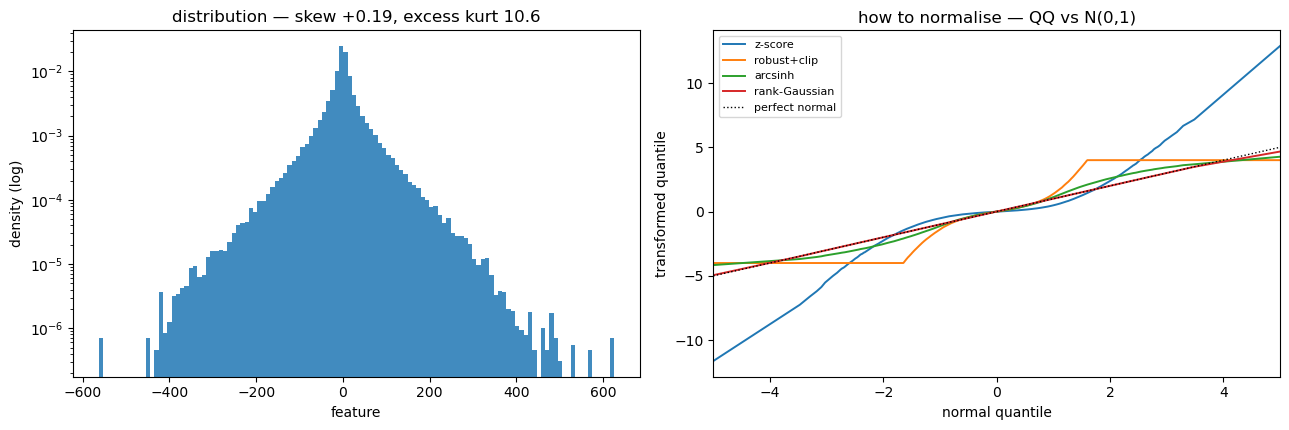

In [5]:
src = KEYS[0]                                                                 # one leg shown; same recipe for each
f = family[price_span][src]
rep = shaping_report(f)
print(rep)
print("recommended transform:", rep.recommended)

ff = f[np.isfinite(f)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.4))
axA.hist(ff, bins=120, density=True, color="C0", alpha=.85)
axA.set_yscale("log"); axA.set_xlabel("feature"); axA.set_ylabel("density (log)")
axA.set_title(f"distribution — skew {rep.raw_skew:+.2f}, excess kurt {rep.raw_excess_kurt:.1f}")
q = np.sort(np.random.default_rng(0).standard_normal(len(ff)))                # reference normal quantiles
sub = np.linspace(0, len(ff) - 1, 4000).astype(int)
for name, v in rep.candidates.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.4, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("transformed quantile")
axB.set_title("how to normalise — QQ vs N(0,1)"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 3. Single exchange or per-exchange?

For a feature that fans out into one leg per venue, does keeping **every** leg add over the single best one,
out-of-sample? Keep all (per-exchange) if they genuinely differ; collapse to one if not. We never merge the
legs into one averaged value.

In [6]:
pc = per_exchange_vs_single(ctx, family, price_span, ctx.price_target, mirror=spec.mirror)
print(f"per-exchange (all legs jointly) {pc['per_exchange']:+.3f}   "
      f"best single ({pc['best_single']['source']}) {pc['best_single']['ic']:+.3f}   "
      f"-> {'keep per-exchange' if pc['adds_over_single'] else 'single exchange suffices'}")

per-exchange (all legs jointly) +0.663   best single (bin) +0.619   -> keep per-exchange


## 4. Ship checklist

- [ ] the streaming (constant-work-per-event) builder, matching the analysis — **done** (`boba.features.ofi_ema`, parity-checked)
- [ ] the tests, passing — `tests/test_ofi.py`, `tests/test_selection.py`, `tests/test_shaping.py`
- [ ] the gate results recorded (with any failures justified) — screening verdict
- [ ] the chosen heads and time-scales written down, with the yardstick spans (`YARDSTICK_N`)
- [ ] the data quirks handled (snapshot-stale sizes; the right price source per exchange) — in `build_context`

**The finalised recipe:** feed the **signed** feature to **both heads**, **every leg**, at the spans picked
above (price head + rate head), shaped with the recommended transform. Then validate out-of-sample across
blocks (the `tools/oss` harness) before shipping.